In [2]:
import numpy as np
import matplotlib.pyplot as plt#

## Hamiltonian energy for double pendulum

# Variables

In [3]:
#Value of gravitational acceleration
g = 1

#Length and mass of the top rod
l1 = 1
m1 = 1
#Length and mass of the second rod
l2 = l1
m2 = 1

#Combined mass
M = m1+m2


# Main Body

In [4]:
#Define the function
def RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h):
    
    #Initialise the arrays to be used
    # t is an array containing each of the timepoints that we will step forward to
    t = np.arange(0,t1+h,h)
    # n is the number of timesteps in t
    n = np.shape(t)[0]
    # theta starts as an empty array, but we will fill in the values we calculate in the loop, below
    theta1 = np.zeros(n)
    theta2 = np.zeros(n)
    #same for velocities
    v1 = np.zeros(n)
    v2 = np.zeros(n)
    
    
    
    #Set the initial value of x and v
    theta1[0] = theta1_0
    v1[0] = v1_0
    theta2[0] = theta2_0
    v2[0] = v2_0
    
    #define F(theta) for coupled equation 1
    def F1(theta1, theta2, v1, v2):
        
        thetaDiff = theta1-theta2
        a = m1 + m2*(np.sin(thetaDiff))**2
        
        return (-np.sin(thetaDiff)*(m2*l1*v1**2*np.cos(thetaDiff)+m2*l2*v2**2)-g*(M*np.sin(theta1)-m2*np.sin(theta2)*np.cos(thetaDiff)))/(l1*a)
    
    #Define G(v) for coupled equation 2
    def G1(v1):
        
        return v1
    
        #define F(theta) for coupled equation 1
    def F2(theta1, theta2, v1, v2):
        
        thetaDiff = theta1-theta2
        a = m1 + m2*(np.sin(thetaDiff))**2
        
        return (np.sin(thetaDiff)*(M*l1*v1**2+m2*l2*v2**2*np.cos(thetaDiff))+g*(M*np.sin(theta1)*np.cos(thetaDiff)-M*np.sin(theta2)))/(l2*a)
    
    #Define G(v) for coupled equation 2
    def G2(v2):
        
        return v2
    
    
    #Loop over the time values and calculate the derivatives
    for i in range(1,n): 
        
        # Calculate the Runge - Kutta intermediate values for both formulas
        f1 = h * F1(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
        f2 = h * F1(theta1[i-1]+f1/2, theta2[i-1]+f1/2, v1[i-1]+f1/2, v2[i-1]+f1/2)
        f3 = h * F1(theta1[i-1]+f2/2, theta2[i-1]+f2/2, v1[i-1]+f2/2, v2[i-1]+f2/2)
        f4 = h * F1(theta1[i-1]+f3, theta2[i-1]+f3, v1[i-1]+f3, v2[i-1]+f3)
        
        g1 = h * G1(v1[i-1])
        g2 = h * G1(v1[i-1]+g1/2)
        g3 = h * G1(v1[i-1]+g2/2)
        g4 = h * G1(v1[i-1]+g3)
        
        e1 = h * F2(theta1[i-1], theta2[i-1], v1[i-1], v2[i-1])
        e2 = h * F2(theta1[i-1]+e1/2, theta2[i-1]+e1/2, v1[i-1]+e1/2, v2[i-1]+e1/2)
        e3 = h * F2(theta1[i-1]+e2/2, theta2[i-1]+e2/2, v1[i-1]+e2/2, v2[i-1]+e2/2)
        e4 = h * F2(theta1[i-1]+e3, theta2[i-1]+e3, v1[i-1]+e3, v2[i-1]+e3)
        
        j1 = h * G2(v2[i-1])
        j2 = h * G2(v2[i-1]+j1/2)
        j3 = h * G2(v2[i-1]+j2/2)
        j4 = h * G2(v2[i-1]+j3)
        
        theta1[i] = theta1[i-1] + 1/6 * (g1 + 2*g2 + 2*g3 + g4)
        v1[i] = v1[i-1] + 1/6 * (f1 + 2*f2 + 2*f3 + f4)
        
        theta2[i] = theta2[i-1] + 1/6 * (j1 + 2*j2 + 2*j3 + j4)
        v2[i] = v2[i-1] + 1/6 * (e1 + 2*e2 + 2*e3 + e4)
        
        if theta1[i] >= 2*np.pi:
            theta1[i] = theta1[i]-2*np.pi
        if theta1[i] <= -2*np.pi:
            theta1[i] = theta1[i]+2*np.pi
        if theta2[i] >= 2*np.pi:
            theta2[i] = theta2[i]-2*np.pi
        if theta2[i] <= -2*np.pi:
            theta2[i] = theta2[i]+2*np.pi
        
    return(t,theta1,theta2,v1,v2) 

In [5]:
#Setting up function for Poincare sections to be used later

def Poincare(theta1, theta2, v2):
    
    crossTheta2 = np.array([])
    crossV2 = np.array([])
    for i in range(len(theta1)-1):
        #Test to see if theta1 crosses 0
        if theta1[i] <= 0 and theta1[i+1] >= 0:
            crossTheta2=np.append(crossTheta2,theta2[i])
            crossV2=np.append(crossV2,v2[i])
            
        elif theta1[i] >= 0 and theta1[i+1] <= 0:
            crossTheta2=np.append(crossTheta2,theta2[i])
            crossV2=np.append(crossV2,v2[i])
            
        elif np.abs(theta1[i]) <= 0.01 and np.abs(theta1[i+1]) >= 2*np.pi*0.01:
            crossTheta2=np.append(crossTheta2,theta2[i])
            crossV2=np.append(crossV2,v2[i])
            
        elif np.abs(theta1[i]) >= 2*np.pi-0.01 and np.abs(theta1[i+1]) <= 0.01:
            crossTheta2=np.append(crossTheta2,theta2[i])
            crossV2=np.append(crossV2,v2[i])
    
    return crossTheta2, crossV2

# Ratios Between Different Variables, Small Angles

## Lengths 1 and 2

### Lissajou

[]

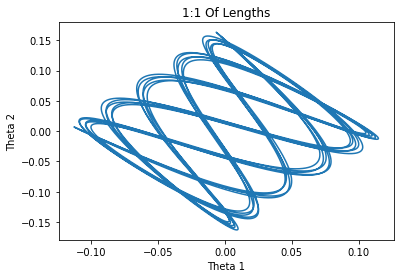

In [5]:
t1 = 50

m1=1
m2=m1


theta1_0 = 0
theta2_0 = 0.15

v1_0 = 0
v2_0 = v1_0

h = 0.0005

l1 = 0.25
l2 = l1
t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)

plt.plot(theta1, theta2)
plt.title("1:1 Of Lengths")
plt.xlabel("Theta 1")
plt.ylabel("Theta 2")
plt.plot()

[]

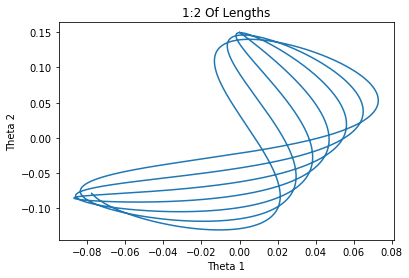

In [ ]:
t1 = 10

theta1_0 = 0
theta2_0 = 0.15

v1_0 = 0
v2_0 = v1_0

h = 0.0005

l1 = 0.25
l2 = 2*l1
t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)

plt.plot(theta1, theta2)
plt.title("1:2 Of Lengths")
plt.xlabel("Theta 1")
plt.ylabel("Theta 2")
plt.plot()

[]

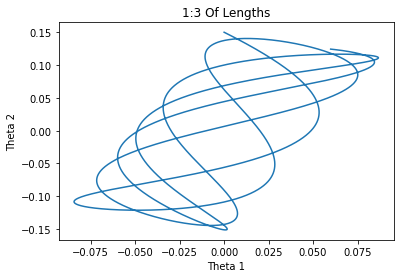

In [ ]:
t1 = 10

theta1_0 = 0
theta2_0 = 0.15

v1_0 = 0
v2_0 = v1_0

h = 0.0005

l1 = 0.25
l2 = 3*l1
t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)

plt.plot(theta1, theta2)
plt.title("1:3 Of Lengths")
plt.xlabel("Theta 1")
plt.ylabel("Theta 2")
plt.plot()

[]

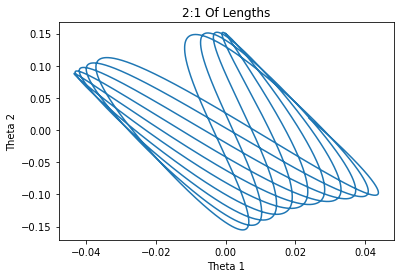

In [ ]:
t1 = 10

theta1_0 = 0
theta2_0 = 0.15

v1_0 = 0
v2_0 = v1_0

h = 0.0005

l1 = 0.25
l2 = 0.5*l1
t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)

plt.plot(theta1, theta2)
plt.title("2:1 Of Lengths")
plt.xlabel("Theta 1")
plt.ylabel("Theta 2")
plt.plot()

[]

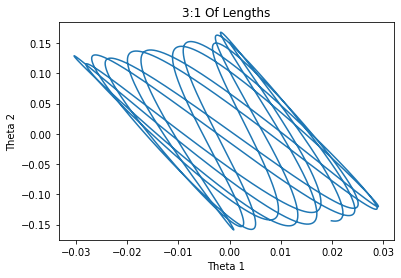

In [ ]:
t1 = 10

theta1_0 = 0
theta2_0 = 0.15

v1_0 = 0
v2_0 = v1_0

h = 0.0005

l1 = 0.25
l2 = 1/3*l1
t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)

plt.plot(theta1, theta2)
plt.title("3:1 Of Lengths")
plt.xlabel("Theta 1")
plt.ylabel("Theta 2")
plt.plot()

[]

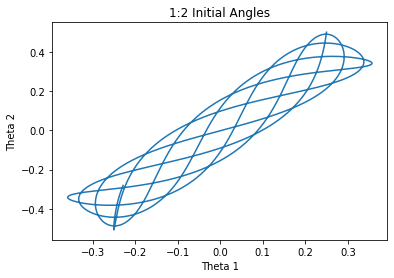

In [29]:
t1 = 15

theta1_0 = 0.25
theta2_0 = theta1_0*2

v1_0 = 0
v2_0 = v1_0

h = 0.0005

l1 = 0.25
l2 = l1
t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)

plt.plot(theta1, theta2)
plt.title("1:2 Initial Angles")
plt.xlabel("Theta 1")
plt.ylabel("Theta 2")
plt.plot()

[]

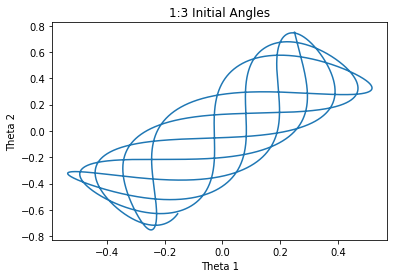

In [28]:
t1 = 15

theta1_0 = 0.25
theta2_0 = theta1_0*3

v1_0 = 0
v2_0 = v1_0

h = 0.0005

l1 = 0.25
l2 = l1
t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)

plt.plot(theta1, theta2)
plt.title("1:3 Initial Angles")
plt.xlabel("Theta 1")
plt.ylabel("Theta 2")
plt.plot()

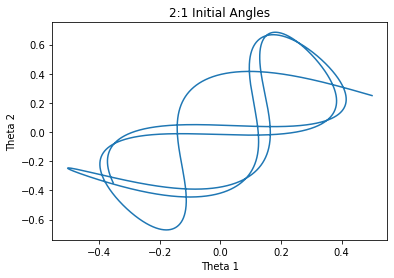

In [34]:
t1 = 10
theta2_0 =0.25
theta1_0 = 0.25*2


v1_0 = 0
v2_0 = v1_0

h = 0.0005

l1 = 0.25
l2 = l1
t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)

plt.plot(theta1, theta2)
plt.title("2:1 Initial Angles")
plt.xlabel("Theta 1")
plt.ylabel("Theta 2")
plt.show()

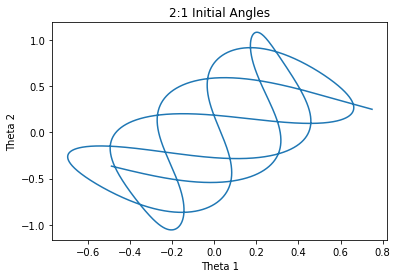

In [37]:
t1 = 10
theta2_0 =0.25
theta1_0 = 0.25*3


v1_0 = 0
v2_0 = v1_0

h = 0.0005

l1 = 0.25
l2 = l1
t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)

plt.plot(theta1, theta2)
plt.title("2:1 Initial Angles")
plt.xlabel("Theta 1")
plt.ylabel("Theta 2")
plt.show()

### Poincare for same mass

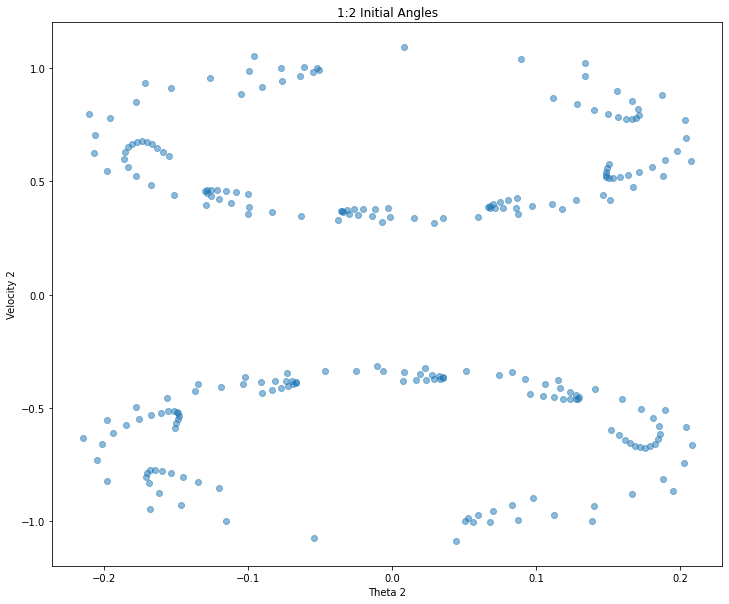

In [38]:
t1 = 500

theta1_0 = 0.25
theta2_0 = theta1_0*2

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.5)
plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.show()

## Small investigation between step sizes for presentation

In [6]:
import time as time

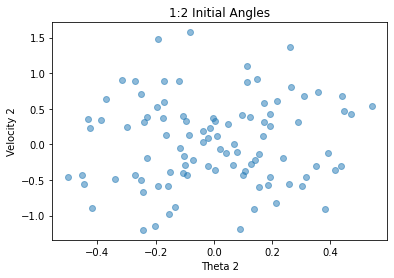

Duration: 11.029051303863525 seconds


In [14]:
start_time=time.time()

t1 = 200

theta1_0 = 0.25
theta2_0 = theta1_0*2

v1_0 = 0
v2_0 = v1_0

h = 0.001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.5)
plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.show()

end_time=time.time()
print(f"Duration: {end_time - start_time} seconds")

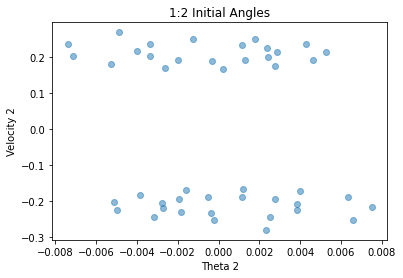

Execution time: 81.43946838378906 seconds


In [8]:
start_time = time.time()

m1=1
m2=30

M=m1+m2

t1 = 100

theta1_0 = 0.15
theta2_0 = theta1_0

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.5)
plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.show()

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

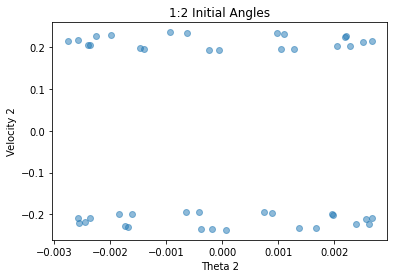

Execution time: 802.5137493610382 seconds


In [9]:
start_time = time.time()


m1=1
m2=30

M=m1+m2

t1 = 100

theta1_0 = 0.15
theta2_0 = theta1_0

v1_0 = 0
v2_0 = v1_0

h = 0.00001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.5)
plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.show()

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

In [1]:
1139.2480947971344/60

18.987468246618906

In [17]:
start_time = time.time()


t1 = 200

theta1_0 = 0.25
theta2_0 = theta1_0*2

v1_0 = 0
v2_0 = v1_0

h = 0.000005

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.scatter(crossTheta2, crossV2,alpha=0.5)
plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.show()

end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

KeyboardInterrupt: 

In [ ]:
1139/60

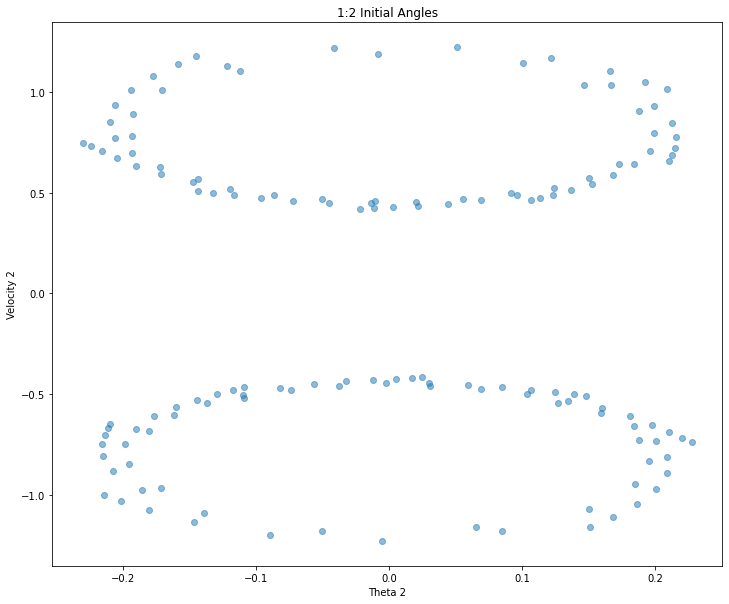

In [23]:
# Different starting angle to see if it changes plot

t1 = 300

theta1_0 = 0.30
theta2_0 = theta1_0*2

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.figure(figsize=(12,10))
plt.scatter(crossTheta2, crossV2,alpha=0.5)
plt.title("1:2 Initial Angles")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.show()

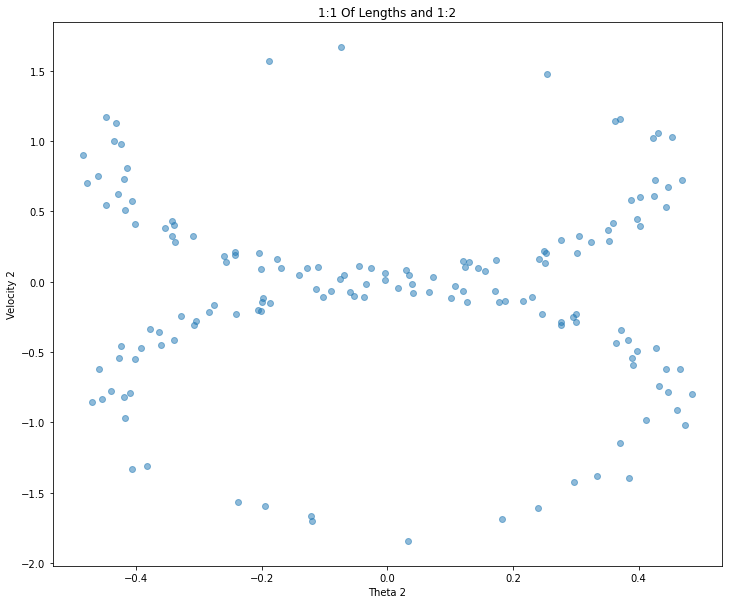

In [22]:
t1 = 300

theta1_0 = 0.25
theta2_0 = theta1_0*3

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)
plt.figure(figsize=(12,10))
plt.scatter(crossTheta2, crossV2,alpha=0.5)
plt.title("1:3 Initial Angles")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.show()

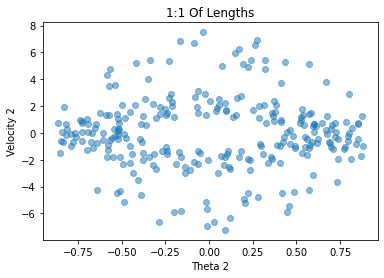

267


In [ ]:
t1 = 100

theta1_0 = 0
theta2_0 = np.pi/6

v1_0 = 1
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)

# Checking how step size effects number of crosses
print(len(crossTheta2))

plt.scatter(crossTheta2, crossV2, alpha=0.5)
plt.title("1:1 Of Lengths")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.show()

[]

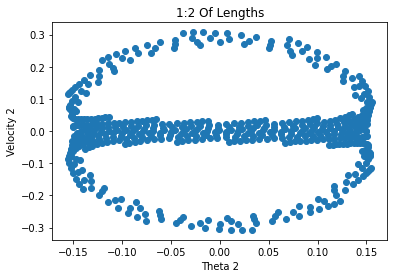

In [ ]:
t1 = 500

theta1_0 = 0
theta2_0 = 0.15

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = 2*l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)

plt.scatter(crossTheta2, crossV2)
plt.title("1:2 Of Lengths")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.plot()

[]

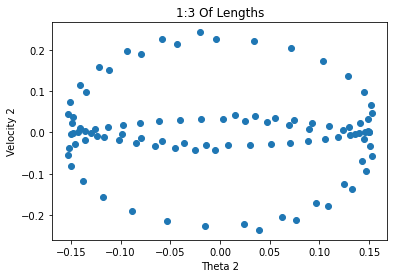

In [ ]:
t1 = 100

theta1_0 = 0
theta2_0 = 0.15

v1_0 = 0
v2_0 = v1_0

h = 0.0005

l1 = 0.25
l2 = 3*l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)

plt.scatter(crossTheta2, crossV2)
plt.title("1:3 Of Lengths")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.plot()

[]

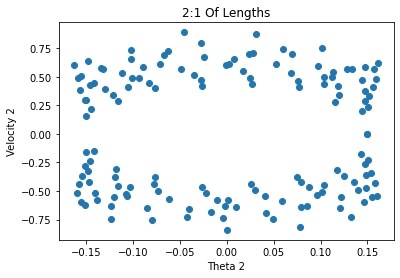

In [ ]:
t1 = 100

theta1_0 = 0
theta2_0 = 0.15

v1_0 = 0
v2_0 = v1_0

h = 0.0005

l1 = 0.25
l2 = 0.5*l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)

plt.scatter(crossTheta2, crossV2)
plt.title("2:1 Of Lengths")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.plot()

[]

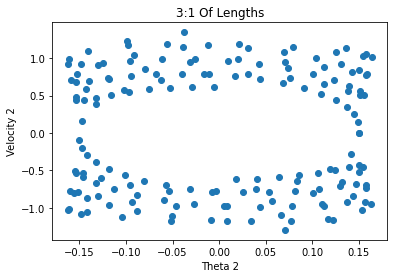

In [ ]:
t1 = 100

theta1_0 = 0
theta2_0 = 0.15

v1_0 = 0
v2_0 = v1_0

h = 0.0005

l1 = 0.25
l2 = 1/3*l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)

plt.scatter(crossTheta2, crossV2)
plt.title("3:1 Of Lengths")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.plot()

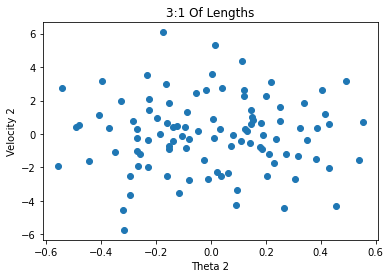

In [ ]:
t1 = 100

m1=1
m2=m1

theta1_0 = 0
theta2_0 = 0.15

v1_0 = 1
v2_0 = v1_0

h = 0.0005

l1 = 0.25
l2 = 1/3*l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)

plt.scatter(crossTheta2, crossV2)
plt.title("3:1 Of Lengths")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.show()

## Poincare for different mass ratios

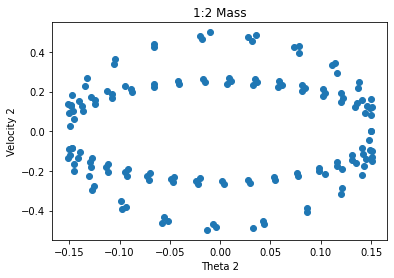

In [7]:
t1 = 100

m1=1
m2=2*m1

M=m1+m2

theta1_0 = 0
theta2_0 = 0.15

v1_0 = 0
v2_0 = v1_0

h = 0.0001

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, h)
crossTheta2, crossV2 = Poincare(theta1, theta2, v2)

plt.scatter(crossTheta2, crossV2)
plt.title("1:2 Mass")
plt.xlabel("Theta 2")
plt.ylabel("Velocity 2")
plt.show()

# Visualisation

In [6]:
from PIL import Image
import time, os

In [8]:
t1 = 50
m1=1
m2=10
M=m1+m2
theta1_0 = 0
theta2_0 = 0

v1_0 = 10
v2_0 = 0

h = 0.0005

l1 = 0.25
l2 = l1

t, theta1,theta2, v1,v2 = RK4(t1, theta1_0, theta2_0, v1_0, v2_0, g, 0.0005)

x1 = l1*np.sin(theta1)
y1 = -l1*np.cos(theta1)

x2 = x1 + l2*np.sin(theta2)
y2 = y1 - l2*np.cos(theta2)

frames = []
for i in range(len(x1)):
    if i%50 == 0:
        fig=plt.figure()
        plt.plot((0, x1[i]), (0, y1[i]))
        plt.plot((x1[i], x2[i]), (y1[i], y2[i]))
        plt.xlim(-1, 1)
        plt.ylim(-0.6, 0.6)
    
        canvas = plt.get_current_fig_manager().canvas
        canvas.draw()
        im = Image.frombytes('RGB', canvas.get_width_height(), canvas.tostring_rgb())
        frames.append(im)
            
    plt.close(fig)
    #plt.show(fig)

frames[0].save("Double Pendulum.gif", format='GIF', append_images=frames[1:], save_all=True, duration=100, loop=0)

/tmp/ipykernel_711565/2422405118.py:30: RuntimeWarning: overflow encountered in scalar power
  return (-np.sin(thetaDiff)*(m2*l1*v1**2*np.cos(thetaDiff)+m2*l2*v2**2)-g*(M*np.sin(theta1)-m2*np.sin(theta2)*np.cos(thetaDiff)))/(l1*a)
/tmp/ipykernel_711565/2422405118.py:30: RuntimeWarning: invalid value encountered in scalar multiply
  return (-np.sin(thetaDiff)*(m2*l1*v1**2*np.cos(thetaDiff)+m2*l2*v2**2)-g*(M*np.sin(theta1)-m2*np.sin(theta2)*np.cos(thetaDiff)))/(l1*a)
/tmp/ipykernel_711565/2422405118.py:43: RuntimeWarning: overflow encountered in scalar power
  return (np.sin(thetaDiff)*(M*l1*v1**2+m2*l2*v2**2*np.cos(thetaDiff))+g*(M*np.sin(theta1)*np.cos(thetaDiff)-M*np.sin(theta2)))/(l2*a)
/tmp/ipykernel_711565/2422405118.py:43: RuntimeWarning: invalid value encountered in scalar multiply
  return (np.sin(thetaDiff)*(M*l1*v1**2+m2*l2*v2**2*np.cos(thetaDiff))+g*(M*np.sin(theta1)*np.cos(thetaDiff)-M*np.sin(theta2)))/(l2*a)


### References

For Runga-Kutte: https://www.physics.umd.edu/hep/drew/pendulum2.html